# ESM-C SAE Layer Ensemble Analysis

This notebook investigates ways to combine multiple fixed DeltaEmbSAE model/layer outputs for BRCA1 while excluding ESM2 entirely. It reuses the artifacts produced by `lower_context.ipynb`, including the layer-level Spearman/AUC table, fixed SAE reconstruction table, and per-layer fitness CSVs.

Analyses covered here:

- Rank ensembles over ESM-C SAE layers using median, best, and worst rank.
- Collections: all ESM-C SAE layers, top AUC, top MaveDB Spearman, top SAE reconstruction R2, and a balanced AUC/Spearman/reconstruction subset.
- PCA-concatenated SAE inference: per selected SAE, fit PCA to SAE activations, keep the globally most important PCs up to `PCA_MAX_COMPONENTS`, concatenate those coordinates, run popDMS inference, and save the gamma consistency plot.

I interpret "MaveDB reconstruction" as the SAE reconstruction R2 computed on the MaveDB variant feature table, and also include a top MaveDB-Spearman collection so both readings are available.

In [1]:
from pathlib import Path
import os
import pickle
import subprocess
import sys
import importlib

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

import lower_context_helpers as h
h = importlib.reload(h)

sns.set_theme(style="darkgrid")
paths = h.default_brca1_paths(REPO_ROOT)
paths

BRCA1Paths(repo_root=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS'), data_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/mavedb_data'), analysis_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae'), baseline_analysis_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_experimental'), sequence_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data'), figure_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures'), table_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables'), job_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs'), baseline_table_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_experimental/tables'),

## Configuration

`SUBMIT_JOB` is `False` by default, so running this notebook writes the payload and Slurm script without submitting. Set it to `True` after reviewing `tasks_df`. PCA jobs are the expensive part; the rank ensembles are lightweight but are included in the same array for reproducibility.

In [2]:
DATASET_NAME = "BRCA1"
EMBEDDING_TYPE = "max_pool"
FIGURE_DPI = 450

OUTPUT_ROOT = paths.analysis_dir / "esmc_sae_layer_ensemble_analysis"
JOB_ROOT = paths.job_dir / "esmc_sae_layer_ensemble_analysis"
for directory in [OUTPUT_ROOT, JOB_ROOT, OUTPUT_ROOT / "metrics", OUTPUT_ROOT / "fitness", OUTPUT_ROOT / "figures"]:
    directory.mkdir(parents=True, exist_ok=True)

COLLECTION_TOP_N = 12
BALANCED_PER_MODEL = 4
RANK_AGGREGATIONS = ["rank_median", "rank_worst", "rank_best"]

PCA_MAX_COMPONENTS = 1000
PCA_PER_SOURCE_COMPONENTS = 64
PCA_STANDARDIZE_INPUTS = True
PCA_IMPORTANCE_METRIC = "explained_variance_ratio"
PCA_RANDOM_SEED = 42

CREATE_JOB = True
SUBMIT_JOB = False
CREATE_MAVEDB_GAMMA_JOB = True
SUBMIT_MAVEDB_GAMMA_JOB = False
MAX_ACTIVE_TASKS = 4
PYTHON_EXECUTABLE = "python3"
SLURM_PARTITION = "any_cpu"
SLURM_CPUS_PER_TASK = 4
SLURM_MEM = "48G"
SLURM_TIME = "12:00:00"

RUN_LOCAL_SMOKE_TASK = False
LOCAL_SMOKE_TASK_IDX = 0

print(f"Output root: {OUTPUT_ROOT}")
print(f"Gamma diagnostics plots will be under: {OUTPUT_ROOT / 'pca_concat'}")


Output root: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis
Gamma diagnostics plots will be under: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat


## Load Existing Tables And Build ESM-C Collections

The helper filters source rows to `biohub/ESMC-*` / `ESMC-*` rows only and excludes layer 0. If ESM-C 6B artifacts are added later, they will be included automatically once they appear in the metrics tables.

In [3]:
runner = h.processed_brca1_runner(paths, model_name="biohub/ESMC-300M", dataset_name=DATASET_NAME, embedding_type=EMBEDDING_TYPE)
metrics_df = h.load_metrics_table(paths.spearman_auc_table_path)
sae_metrics_df = pd.read_csv(paths.fixed_sae_metrics_path) if paths.fixed_sae_metrics_path.is_file() else pd.DataFrame()

collections = h.build_esmc_sae_collections(
    metrics_df,
    sae_metrics_df,
    embedding_type=EMBEDDING_TYPE,
    top_n=COLLECTION_TOP_N,
    balanced_per_model=BALANCED_PER_MODEL,
)
assert collections, "No ESM-C SAE collections were found. Run/collect lower_context.ipynb first."
assert all(h.is_esmc_row(rows).all() for rows in collections.values()), "A non-ESM-C row leaked into an ESM-C collection."

collection_summary = pd.DataFrame([
    {
        "collection_name": name,
        "n_layers": len(rows),
        "models": ", ".join(sorted(rows["model_short"].dropna().astype(str).unique())),
        "layer_min": int(rows["layer"].min()) if len(rows) else np.nan,
        "layer_max": int(rows["layer"].max()) if len(rows) else np.nan,
        "mean_auc": rows["auc"].mean(),
        "mean_spearman": rows["spearman_rho"].mean(),
        "mean_reconstruction_r2": rows.get("reconstruction_r2", pd.Series(dtype=float)).mean(),
    }
    for name, rows in collections.items()
])
collection_summary.to_csv(OUTPUT_ROOT / "esmc_sae_collection_summary.csv", index=False)
display(collection_summary)

,collection_name,n_layers,models,layer_min,layer_max,mean_auc,mean_spearman,mean_reconstruction_r2
0,all_esmc_sae_layers,66,"ESMC-300M, ESMC-600M",1,36,0.912153,0.340884,0.747386
1,best_auc_top12,12,"ESMC-300M, ESMC-600M",5,36,0.939883,0.394799,0.562070
2,best_mavedb_spearman_top12,12,"ESMC-300M, ESMC-600M",13,36,0.936758,0.403797,0.561403
3,best_reconstruction_r2_top12,12,"ESMC-300M, ESMC-600M",5,19,0.910906,0.322089,0.950957
4,balanced_auc_spearman_reconstruction_top4_per_...,8,"ESMC-300M, ESMC-600M",15,35,0.930434,0.393690,0.791269


In [4]:
preview_rows = []
for name, rows in collections.items():
    preview = rows.sort_values(["auc", "spearman_rho"], ascending=[False, False]).head(8).copy()
    preview.insert(0, "collection_name", name)
    preview_rows.append(preview)
collection_preview_df = pd.concat(preview_rows, ignore_index=True, sort=False)
display(
    collection_preview_df[
        ["collection_name", "model_short", "layer", "auc", "spearman_rho", "reconstruction_r2", "feature_path", "fitness_path"]
    ].assign(
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        reconstruction_r2=lambda df: pd.to_numeric(df["reconstruction_r2"], errors="coerce").round(3),
    )
)

,collection_name,model_short,layer,auc,spearman_rho,reconstruction_r2,feature_path,fitness_path
0,all_esmc_sae_layers,ESMC-600M,36.0,0.961,0.449,-0.319,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,all_esmc_sae_layers,ESMC-300M,30.0,0.952,0.439,-0.633,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,all_esmc_sae_layers,ESMC-300M,29.0,0.947,0.415,0.708,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,all_esmc_sae_layers,ESMC-600M,32.0,0.943,0.421,0.717,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,all_esmc_sae_layers,ESMC-600M,30.0,0.936,0.389,0.757,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
5,all_esmc_sae_layers,ESMC-600M,6.0,0.936,0.333,0.865,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
6,all_esmc_sae_layers,ESMC-600M,5.0,0.936,0.340,0.857,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
7,all_esmc_sae_layers,ESMC-600M,34.0,0.936,0.424,0.686,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
8,best_auc_top12,ESMC-600M,36.0,0.961,0.449,-0.319,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
9,best_auc_top12,ESMC-300M,30.0,0.952,0.439,-0.633,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Build Slurm Tasks

Rank tasks cover every collection and each requested rank aggregation. PCA-concat tasks run once per collection and save the cross-replicate gamma consistency plot for that inferred concatenated feature space.

In [5]:
def _pretty_collection_label(name):
    return name.replace("_", " ").replace("top", "top ")

rank_collections = list(collections)
pca_collections = [
    "all_esmc_sae_layers",
    f"best_auc_top{COLLECTION_TOP_N}",
    f"best_mavedb_spearman_top{COLLECTION_TOP_N}",
    f"best_reconstruction_r2_top{COLLECTION_TOP_N}",
    f"balanced_auc_spearman_reconstruction_top{BALANCED_PER_MODEL}_per_model",
]
pca_collections = [name for name in pca_collections if name in collections]

tasks = []
for collection_name in rank_collections:
    for aggregation in RANK_AGGREGATIONS:
        label = f"{_pretty_collection_label(collection_name)} {aggregation.replace('rank_', '')} rank"
        tasks.append({
            "task_type": "rank_ensemble",
            "collection_name": collection_name,
            "aggregation": aggregation,
            "method_label": label,
            "short_label": label.replace("all esmc sae layers", "all ESMC"),
        })

crossrep_pca_tasks = []
for collection_name in pca_collections:
    label = f"{_pretty_collection_label(collection_name)} PCA concat"
    crossrep_pca_tasks.append({
        "task_type": "pca_concat",
        "collection_name": collection_name,
        "method_label": f"{label} (consistency gamma)",
        "short_label": f"{label.replace('all esmc sae layers', 'all ESMC')} consistency gamma",
        "max_components": PCA_MAX_COMPONENTS,
        "per_source_components": PCA_PER_SOURCE_COMPONENTS,
        "standardize": PCA_STANDARDIZE_INPUTS,
        "importance_metric": PCA_IMPORTANCE_METRIC,
        "seed": PCA_RANDOM_SEED,
        "gamma_selection_objective": "cross_replicate_consistency",
    })
tasks.extend(crossrep_pca_tasks)

mavedb_gamma_tasks = []
for collection_name in pca_collections:
    label = f"{_pretty_collection_label(collection_name)} PCA concat"
    mavedb_gamma_tasks.append({
        "task_type": "pca_concat",
        "collection_name": collection_name,
        "method_label": f"{label} (MaveDB gamma)",
        "short_label": f"{label.replace('all esmc sae layers', 'all ESMC')} MaveDB gamma",
        "max_components": PCA_MAX_COMPONENTS,
        "per_source_components": PCA_PER_SOURCE_COMPONENTS,
        "standardize": PCA_STANDARDIZE_INPUTS,
        "importance_metric": PCA_IMPORTANCE_METRIC,
        "seed": PCA_RANDOM_SEED,
        "gamma_selection_objective": "mavedb_spearman",
    })

tasks_df = pd.DataFrame(tasks)
tasks_df.insert(0, "task_idx", range(len(tasks_df)))
tasks_df["n_source_layers"] = tasks_df["collection_name"].map(lambda name: len(collections[name]))
tasks_df.to_csv(OUTPUT_ROOT / "esmc_sae_ensemble_tasks.csv", index=False)

mavedb_gamma_tasks_df = pd.DataFrame(mavedb_gamma_tasks)
mavedb_gamma_tasks_df.insert(0, "task_idx", range(len(mavedb_gamma_tasks_df)))
mavedb_gamma_tasks_df["n_source_layers"] = mavedb_gamma_tasks_df["collection_name"].map(lambda name: len(collections[name]))
mavedb_gamma_tasks_df.to_csv(OUTPUT_ROOT / "esmc_sae_ensemble_mavedb_gamma_tasks.csv", index=False)

display(tasks_df)
display(mavedb_gamma_tasks_df)


,task_idx,task_type,collection_name,aggregation,method_label,short_label,max_components,per_source_components,standardize,importance_metric,seed,gamma_selection_objective,n_source_layers
0,0,rank_ensemble,all_esmc_sae_layers,rank_median,all esmc sae layers median rank,all ESMC median rank,NaN,NaN,NaN,NaN,NaN,NaN,66
1,1,rank_ensemble,all_esmc_sae_layers,rank_worst,all esmc sae layers worst rank,all ESMC worst rank,NaN,NaN,NaN,NaN,NaN,NaN,66
2,2,rank_ensemble,all_esmc_sae_layers,rank_best,all esmc sae layers best rank,all ESMC best rank,NaN,NaN,NaN,NaN,NaN,NaN,66
3,3,rank_ensemble,best_auc_top12,rank_median,best auc top 12 median rank,best auc top 12 median rank,NaN,NaN,NaN,NaN,NaN,NaN,12
4,4,rank_ensemble,best_auc_top12,rank_worst,best auc top 12 worst rank,best auc top 12 worst rank,NaN,NaN,NaN,NaN,NaN,NaN,12
5,5,rank_ensemble,best_auc_top12,rank_best,best auc top 12 best rank,best auc top 12 best rank,NaN,NaN,NaN,NaN,NaN,NaN,12
6,6,rank_ensemble,best_mavedb_spearman_top12,rank_median,best mavedb spearman top 12 median rank,best mavedb spearman top 12 median rank,NaN,NaN,NaN,NaN,NaN,NaN,12
7,7,rank_ensemble,best_mavedb_spearman_top12,rank_worst,best mavedb spearman top 12 worst rank,best mavedb spearman top 12 worst rank,NaN,NaN,NaN,NaN,NaN,NaN,12
8,8,rank_ensemble,best_mavedb_spearman_top12,rank_best,best mavedb spearman top 12 best rank,best mavedb spearman top 12 best rank,NaN,NaN,NaN,NaN,NaN,NaN,12
9,9,rank_ensemble,best_reconstruction_r2_top12,rank_median,best reconstruction r2 top 12 median rank,best reconstruction r2 top 12 median rank,NaN,NaN,NaN,NaN,NaN,NaN,12


,task_idx,task_type,collection_name,method_label,short_label,max_components,per_source_components,standardize,importance_metric,seed,gamma_selection_objective,n_source_layers
0,0,pca_concat,all_esmc_sae_layers,all esmc sae layers PCA concat (MaveDB gamma),all ESMC PCA concat MaveDB gamma,1000,64,True,explained_variance_ratio,42,mavedb_spearman,66
1,1,pca_concat,best_auc_top12,best auc top 12 PCA concat (MaveDB gamma),best auc top 12 PCA concat MaveDB gamma,1000,64,True,explained_variance_ratio,42,mavedb_spearman,12
2,2,pca_concat,best_mavedb_spearman_top12,best mavedb spearman top 12 PCA concat (MaveDB...,best mavedb spearman top 12 PCA concat MaveDB ...,1000,64,True,explained_variance_ratio,42,mavedb_spearman,12
3,3,pca_concat,best_reconstruction_r2_top12,best reconstruction r2 top 12 PCA concat (Mave...,best reconstruction r2 top 12 PCA concat MaveD...,1000,64,True,explained_variance_ratio,42,mavedb_spearman,12
4,4,pca_concat,balanced_auc_spearman_reconstruction_top4_per_...,balanced auc spearman reconstruction top 4 per...,balanced auc spearman reconstruction top 4 per...,1000,64,True,explained_variance_ratio,42,mavedb_spearman,8


## Write Payload And Slurm Script

The generated worker writes one status JSON per task under `OUTPUT_ROOT/status`. Full task outputs land in `OUTPUT_ROOT/metrics`, `OUTPUT_ROOT/fitness`, and `OUTPUT_ROOT/pca_concat`.

In [6]:
payload = {
    "repo_root": str(REPO_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "dataset_name": DATASET_NAME,
    "embedding_type": EMBEDDING_TYPE,
    "metrics_path": str(paths.spearman_auc_table_path),
    "sae_metrics_path": str(paths.fixed_sae_metrics_path),
    "clinvar_annotation_cache_path": str(paths.clinvar_annotation_cache_path),
    "primary_key": "hgvs_nt",
    "score_col": "score",
    "collection_top_n": COLLECTION_TOP_N,
    "balanced_per_model": BALANCED_PER_MODEL,
    "max_components": PCA_MAX_COMPONENTS,
    "per_source_components": PCA_PER_SOURCE_COMPONENTS,
    "standardize_pca_inputs": PCA_STANDARDIZE_INPUTS,
    "importance_metric": PCA_IMPORTANCE_METRIC,
    "seed": PCA_RANDOM_SEED,
    "tasks": tasks,
}

payload_path = JOB_ROOT / "esmc_sae_layer_ensemble_payload.pkl"
script_path = JOB_ROOT / "submit_esmc_sae_layer_ensemble_array.sh"
log_dir = JOB_ROOT / "logs"

if CREATE_JOB:
    with payload_path.open("wb") as handle:
        pickle.dump(payload, handle)
    h.write_slurm_array_job(
        script_path=script_path,
        payload_path=payload_path,
        runner_script=REPO_ROOT / "job_scripts" / "run_esmc_sae_ensemble_task.py",
        n_tasks=len(tasks),
        job_name="brca1_esmc_sae_ens",
        repo_root=REPO_ROOT,
        log_dir=log_dir,
        partition=SLURM_PARTITION,
        cpus_per_task=SLURM_CPUS_PER_TASK,
        mem=SLURM_MEM,
        time=SLURM_TIME,
        max_active_tasks=MAX_ACTIVE_TASKS,
        python_executable=PYTHON_EXECUTABLE,
    )
    print(f"Cross-replicate payload: {payload_path}")
    print(f"Cross-replicate Slurm script: {script_path}")
    if SUBMIT_JOB:
        completed = subprocess.run(["sbatch", str(script_path)], check=True, capture_output=True, text=True)
        print(completed.stdout.strip())

mavedb_gamma_payload = dict(payload)
mavedb_gamma_payload["tasks"] = mavedb_gamma_tasks
mavedb_gamma_payload["gamma_selection_objective"] = "mavedb_spearman"
mavedb_gamma_payload_path = JOB_ROOT / "esmc_sae_layer_ensemble_mavedb_gamma_payload.pkl"
mavedb_gamma_script_path = JOB_ROOT / "submit_esmc_sae_layer_ensemble_mavedb_gamma_array.sh"

if CREATE_MAVEDB_GAMMA_JOB:
    with mavedb_gamma_payload_path.open("wb") as handle:
        pickle.dump(mavedb_gamma_payload, handle)
    h.write_slurm_array_job(
        script_path=mavedb_gamma_script_path,
        payload_path=mavedb_gamma_payload_path,
        runner_script=REPO_ROOT / "job_scripts" / "run_esmc_sae_ensemble_task.py",
        n_tasks=len(mavedb_gamma_tasks),
        job_name="brca1_esmc_sae_mvg",
        repo_root=REPO_ROOT,
        log_dir=JOB_ROOT / "logs_mavedb_gamma",
        partition=SLURM_PARTITION,
        cpus_per_task=SLURM_CPUS_PER_TASK,
        mem=SLURM_MEM,
        time=SLURM_TIME,
        max_active_tasks=MAX_ACTIVE_TASKS,
        python_executable=PYTHON_EXECUTABLE,
    )
    print(f"MaveDB-gamma payload: {mavedb_gamma_payload_path}")
    print(f"MaveDB-gamma Slurm script: {mavedb_gamma_script_path}")
    if SUBMIT_MAVEDB_GAMMA_JOB:
        completed = subprocess.run(["sbatch", str(mavedb_gamma_script_path)], check=True, capture_output=True, text=True)
        print(completed.stdout.strip())


Cross-replicate payload: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/esmc_sae_layer_ensemble_payload.pkl
Cross-replicate Slurm script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_esmc_sae_layer_ensemble_array.sh
MaveDB-gamma payload: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/esmc_sae_layer_ensemble_mavedb_gamma_payload.pkl
MaveDB-gamma Slurm script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_esmc_sae_layer_ensemble_mavedb_gamma_array.sh


In [7]:
if RUN_LOCAL_SMOKE_TASK:
    completed = subprocess.run(
        [PYTHON_EXECUTABLE, str(REPO_ROOT / "job_scripts" / "run_esmc_sae_ensemble_task.py"), str(payload_path), str(LOCAL_SMOKE_TASK_IDX)],
        check=True,
        capture_output=True,
        text=True,
    )
    print(completed.stdout)

## Collect Finished Task Outputs

Run this section after the Slurm array has finished. It combines every per-task metrics table and writes a single review-star metrics table for downstream plotting.

In [8]:
metrics_files = sorted((OUTPUT_ROOT / "metrics").glob("*_metrics_by_review_stars.csv"))
print(f"Found {len(metrics_files)} metrics file(s).")
if metrics_files:
    esmc_ensemble_metrics_df = pd.concat([pd.read_csv(path) for path in metrics_files], ignore_index=True, sort=False)
    for column in ["gamma_opt", "gamma_plot_path", "gamma_table_path", "gamma_pair_table_path", "gamma_selection_objective", "selected_gamma_mean_pairwise_pearson_r", "selected_gamma_mavedb_spearman", "selected_gamma_grid", "n_selected_components"]:
        if column not in esmc_ensemble_metrics_df.columns:
            esmc_ensemble_metrics_df[column] = np.nan
    def _normalize_gamma_objective(row):
        value = row.get("gamma_selection_objective", "")
        is_blank = pd.isna(value) or str(value).strip() == ""
        if row.get("aggregation") == "pca_concat" and is_blank:
            return "cross_replicate_consistency"
        if is_blank:
            return "not_applicable"
        return value

    esmc_ensemble_metrics_df["gamma_selection_objective"] = esmc_ensemble_metrics_df.apply(_normalize_gamma_objective, axis=1)

    def _gamma_objective_label(row):
        label = str(row["method_label"])
        if row.get("aggregation") != "pca_concat":
            return label
        objective = row.get("gamma_selection_objective")
        if objective == "cross_replicate_consistency" and "gamma" not in label.lower():
            return f"{label} (consistency gamma)"
        if objective == "mavedb_spearman" and "mavedb" not in label.lower():
            return f"{label} (MaveDB gamma)"
        return label

    esmc_ensemble_metrics_df["method_label"] = esmc_ensemble_metrics_df.apply(_gamma_objective_label, axis=1)
    if "short_label" in esmc_ensemble_metrics_df.columns:
        esmc_ensemble_metrics_df["short_label"] = esmc_ensemble_metrics_df.apply(
            lambda row: row["method_label"] if row.get("aggregation") == "pca_concat" else row.get("short_label", row["method_label"]),
            axis=1,
        )
    combined_metrics_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_metrics_by_review_stars.csv"
    esmc_ensemble_metrics_df.to_csv(combined_metrics_path, index=False)
    display(
        esmc_ensemble_metrics_df[
            ["review_filter", "method_label", "aggregation", "model_filter", "gamma_selection_objective", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "gamma_opt", "selected_gamma_mean_pairwise_pearson_r", "selected_gamma_mavedb_spearman", "gamma_plot_path"]
        ].assign(
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
            functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
            selected_gamma_mean_pairwise_pearson_r=lambda df: pd.to_numeric(df["selected_gamma_mean_pairwise_pearson_r"], errors="coerce").round(3),
            selected_gamma_mavedb_spearman=lambda df: pd.to_numeric(df["selected_gamma_mavedb_spearman"], errors="coerce").round(3),
        )
    )
else:
    esmc_ensemble_metrics_df = pd.DataFrame()
    combined_metrics_path = None


Found 25 metrics file(s).


,review_filter,method_label,aggregation,model_filter,gamma_selection_objective,n_component_model_layers,spearman_rho,auc,functional_score_auc,gamma_opt,selected_gamma_mean_pairwise_pearson_r,selected_gamma_mavedb_spearman,gamma_plot_path
0,all binary annotations,all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.931,0.989,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,>= 1 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.939,0.991,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,>= 2 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.962,0.991,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,>= 3 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.978,0.982,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,>= 4 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,NaN,NaN,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,all binary annotations,best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.944,0.989,NaN,NaN,NaN,NaN
121,>= 1 star(s),best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.947,0.991,NaN,NaN,NaN,NaN
122,>= 2 star(s),best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.978,0.991,NaN,NaN,NaN,NaN
123,>= 3 star(s),best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.978,0.982,NaN,NaN,NaN,NaN


## Performance Summary

This table collapses the review-star rows into one row per method/objective and keeps the all-binary MaveDB Spearman plus AUC at all, 1, 2, and 3-star filters.


In [9]:
if not esmc_ensemble_metrics_df.empty:
    performance_summary_df = h.performance_summary_table(esmc_ensemble_metrics_df)
    performance_summary_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_performance_summary.csv"
    performance_summary_df.to_csv(performance_summary_path, index=False)
    display_columns = [
        "spearman_auc_rank",
        "spearman_auc_rank_score",
        "mavedb_spearman_rank",
        "auc_all_binary_rank",
        "method_label",
        "aggregation",
        "model_filter",
        "gamma_selection_objective",
        "n_component_model_layers",
        "n_selected_components",
        "gamma_opt",
        "selected_gamma_mean_pairwise_pearson_r",
        "selected_gamma_mavedb_spearman",
        "mavedb_spearman",
        "auc_all_binary",
        "auc_min_1_stars",
        "auc_min_2_stars",
        "auc_min_3_stars",
    ]
    display(
        performance_summary_df[[col for col in display_columns if col in performance_summary_df.columns]].assign(
            spearman_auc_rank_score=lambda df: pd.to_numeric(df.get("spearman_auc_rank_score", np.nan), errors="coerce").round(2),
            mavedb_spearman_rank=lambda df: pd.to_numeric(df.get("mavedb_spearman_rank", np.nan), errors="coerce").astype("Int64"),
            auc_all_binary_rank=lambda df: pd.to_numeric(df.get("auc_all_binary_rank", np.nan), errors="coerce").astype("Int64"),
            gamma_opt=lambda df: pd.to_numeric(df.get("gamma_opt", np.nan), errors="coerce"),
            selected_gamma_mean_pairwise_pearson_r=lambda df: pd.to_numeric(df.get("selected_gamma_mean_pairwise_pearson_r", np.nan), errors="coerce").round(3),
            selected_gamma_mavedb_spearman=lambda df: pd.to_numeric(df.get("selected_gamma_mavedb_spearman", np.nan), errors="coerce").round(3),
            mavedb_spearman=lambda df: pd.to_numeric(df.get("mavedb_spearman", np.nan), errors="coerce").round(3),
            auc_all_binary=lambda df: pd.to_numeric(df.get("auc_all_binary", np.nan), errors="coerce").round(3),
            auc_min_1_stars=lambda df: pd.to_numeric(df.get("auc_min_1_stars", np.nan), errors="coerce").round(3),
            auc_min_2_stars=lambda df: pd.to_numeric(df.get("auc_min_2_stars", np.nan), errors="coerce").round(3),
            auc_min_3_stars=lambda df: pd.to_numeric(df.get("auc_min_3_stars", np.nan), errors="coerce").round(3),
        )
    )
    print(f"Performance summary ranked by combined MaveDB-Spearman/AUC: {performance_summary_path}")
else:
    performance_summary_df = pd.DataFrame()


,spearman_auc_rank,spearman_auc_rank_score,mavedb_spearman_rank,auc_all_binary_rank,method_label,aggregation,model_filter,gamma_selection_objective,n_component_model_layers,n_selected_components,gamma_opt,selected_gamma_mean_pairwise_pearson_r,selected_gamma_mavedb_spearman,mavedb_spearman,auc_all_binary,auc_min_1_stars,auc_min_2_stars,auc_min_3_stars
0,1,1.5,1,2,best mavedb spearman top 12 worst rank,rank_worst,best_mavedb_spearman_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.449,0.966,0.974,0.991,0.992
1,1,1.5,2,1,best auc top 12 worst rank,rank_worst,best_auc_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.439,0.970,0.973,0.991,0.992
2,3,4.0,3,5,best auc top 12 median rank,rank_median,best_auc_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.432,0.951,0.959,0.978,0.988
3,3,4.0,4,4,balanced auc spearman reconstruction top 4 per...,rank_worst,balanced_auc_spearman_reconstruction_top4_per_...,not_applicable,8,NaN,NaN,NaN,NaN,0.432,0.956,0.964,0.980,0.989
4,5,6.0,6,6,best mavedb spearman top 12 median rank,rank_median,best_mavedb_spearman_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.427,0.945,0.952,0.967,0.989
5,6,6.5,5,8,best mavedb spearman top 12 PCA concat (MaveDB...,pca_concat,best_mavedb_spearman_top12,mavedb_spearman,12,768.0,0.010000,0.787,0.431,0.431,0.938,0.946,0.964,0.968
6,7,7.0,11,3,all esmc sae layers worst rank,rank_worst,all_esmc_sae_layers,not_applicable,66,NaN,NaN,NaN,NaN,0.391,0.958,0.959,0.984,0.987
7,8,8.5,7,10,best mavedb spearman top 12 PCA concat (consis...,pca_concat,best_mavedb_spearman_top12,cross_replicate_consistency,12,768.0,0.183298,NaN,NaN,0.419,0.934,0.942,0.956,0.967
8,9,9.0,9,9,balanced auc spearman reconstruction top 4 per...,rank_median,balanced_auc_spearman_reconstruction_top4_per_...,not_applicable,8,NaN,NaN,NaN,NaN,0.417,0.937,0.944,0.959,0.990
9,10,10.0,8,12,best auc top 12 PCA concat (MaveDB gamma),pca_concat,best_auc_top12,mavedb_spearman,12,768.0,0.020691,0.757,0.418,0.418,0.932,0.939,0.958,0.944


Performance summary ranked by combined MaveDB-Spearman/AUC: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_esmc_sae_layer_ensemble_performance_summary.csv


## Gamma Objective Comparison

After the MaveDB-gamma jobs finish, this compares the selected-gamma replicate consistency, all-binary MaveDB Spearman, and all-binary ClinVar AUC against the cross-replicate gamma jobs for the same PCA collection.


In [10]:
if not performance_summary_df.empty:
    gamma_objective_comparison_df = h.gamma_objective_comparison_table(performance_summary_df)
    gamma_objective_comparison_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_gamma_objective_comparison.csv"
    gamma_objective_comparison_df.to_csv(gamma_objective_comparison_path, index=False)
    display(gamma_objective_comparison_df)
    gamma_objective_comparison_figure_path = paths.figure_dir / "BRCA1_esmc_sae_layer_ensemble_gamma_objective_comparison.png"
    print(f"Gamma objective comparison table: {gamma_objective_comparison_path}")
else:
    gamma_objective_comparison_df = pd.DataFrame()


,model_filter,crossrep_method_label,crossrep_gamma_opt,crossrep_selected_gamma_mean_pairwise_pearson_r,crossrep_selected_gamma_mavedb_spearman,crossrep_mavedb_spearman,crossrep_auc_all_binary,crossrep_auc_min_1_stars,crossrep_auc_min_2_stars,crossrep_auc_min_3_stars,...,mavedb_gamma_auc_all_binary,mavedb_gamma_auc_min_1_stars,mavedb_gamma_auc_min_2_stars,mavedb_gamma_auc_min_3_stars,delta_gamma_opt,delta_mavedb_spearman,delta_auc_all_binary,delta_auc_min_1_stars,delta_auc_min_2_stars,delta_auc_min_3_stars
0,all_esmc_sae_layers,all esmc sae layers PCA concat (consistency ga...,3.359818,NaN,NaN,0.335322,0.911046,0.917829,0.930646,0.928911,...,0.931410,0.938957,0.961633,0.978223,-3.349818,0.078043,0.020364,0.021128,0.030987,0.049312
1,balanced_auc_spearman_reconstruction_top4_per_...,balanced auc spearman reconstruction top 4 per...,127.427499,NaN,NaN,0.307155,0.862651,0.867548,0.898792,0.916646,...,0.912010,0.919380,0.945326,0.963705,-127.384685,0.072799,0.049360,0.051832,0.046534,0.047059
2,best_auc_top12,best auc top 12 PCA concat (consistency gamma),1.623777,NaN,NaN,0.371336,0.920100,0.927377,0.948503,0.944681,...,0.932018,0.938813,0.957668,0.944431,-1.603085,0.046771,0.011919,0.011436,0.009165,-0.000250
3,best_mavedb_spearman_top12,best mavedb spearman top 12 PCA concat (consis...,0.183298,NaN,NaN,0.419258,0.933806,0.941616,0.955646,0.966959,...,0.938132,0.946087,0.963892,0.967710,-0.173298,0.011546,0.004326,0.004470,0.008246,0.000751
4,best_reconstruction_r2_top12,best reconstruction r2 top 12 PCA concat (cons...,0.784760,NaN,NaN,0.303449,0.882631,0.888917,0.907826,0.955444,...,0.912141,0.919554,0.939968,0.960951,-0.774760,0.075931,0.029511,0.030637,0.032143,0.005507


Gamma objective comparison table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_esmc_sae_layer_ensemble_gamma_objective_comparison.csv


## Best Worst-Rank Ensemble Gamma Sweep

This writes a single cluster job for the best MaveDB-Spearman top-12 SAE-layer worst-rank ensemble. The gamma grid starts at 1.0, two orders above the earlier 0.01 minimum, and uses 60 log-spaced steps.

In [11]:
BEST_RANK_GAMMA_COLLECTION = f"best_mavedb_spearman_top{COLLECTION_TOP_N}"
BEST_RANK_GAMMA_AGGREGATION = "rank_worst"
BEST_RANK_GAMMA_MIN = 0.0001
BEST_RANK_GAMMA_MAX = 10
BEST_RANK_GAMMA_STEPS = 20
BEST_RANK_GAMMA_VALUES = np.logspace(
    np.log10(BEST_RANK_GAMMA_MIN),
    np.log10(BEST_RANK_GAMMA_MAX),
    BEST_RANK_GAMMA_STEPS,
)

CREATE_BEST_RANK_GAMMA_SWEEP_JOB = True
SUBMIT_BEST_RANK_GAMMA_SWEEP_JOB = True
RUN_BEST_RANK_GAMMA_SWEEP_LOCALLY = False
BEST_RANK_GAMMA_SWEEP_MEM = "96G"
BEST_RANK_GAMMA_SWEEP_TIME = "18:00:00"

assert BEST_RANK_GAMMA_COLLECTION in collections, f"Missing collection: {BEST_RANK_GAMMA_COLLECTION}"

best_rank_gamma_run_name = f"{BEST_RANK_GAMMA_COLLECTION}_worst_rank_gamma_sweep"
best_rank_gamma_dir = OUTPUT_ROOT / best_rank_gamma_run_name
best_rank_gamma_dir.mkdir(parents=True, exist_ok=True)
best_rank_gamma_log_dir = JOB_ROOT / "logs_best_rank_gamma_sweep"
best_rank_gamma_log_dir.mkdir(parents=True, exist_ok=True)

best_rank_gamma_metrics_path = best_rank_gamma_dir / f"{best_rank_gamma_run_name}_metrics.csv"
best_rank_gamma_component_consistency_path = best_rank_gamma_dir / f"{best_rank_gamma_run_name}_component_consistency.csv"
best_rank_gamma_figure_path = paths.figure_dir / "BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_spearman_auc.png"
best_rank_gamma_payload_path = JOB_ROOT / f"{best_rank_gamma_run_name}_payload.pkl"
best_rank_gamma_script_path = JOB_ROOT / f"submit_{best_rank_gamma_run_name}.sh"
best_rank_gamma_worker_path = REPO_ROOT / "job_scripts" / "run_rank_ensemble_gamma_sweep.py"

best_rank_gamma_payload = {
    "repo_root": str(REPO_ROOT),
    "dataset_name": DATASET_NAME,
    "embedding_type": EMBEDDING_TYPE,
    "metrics_path": str(paths.spearman_auc_table_path),
    "sae_metrics_path": str(paths.fixed_sae_metrics_path),
    "clinvar_annotation_cache_path": str(paths.clinvar_annotation_cache_path),
    "primary_key": "hgvs_nt",
    "score_col": "score",
    "collection_top_n": COLLECTION_TOP_N,
    "balanced_per_model": BALANCED_PER_MODEL,
    "collection_name": BEST_RANK_GAMMA_COLLECTION,
    "aggregation": BEST_RANK_GAMMA_AGGREGATION,
    "gamma_values": BEST_RANK_GAMMA_VALUES,
    "min_review_stars": 0,
    "output_dir": str(best_rank_gamma_dir),
    "metrics_output_path": str(best_rank_gamma_metrics_path),
    "component_consistency_output_path": str(best_rank_gamma_component_consistency_path),
    "figure_output_path": str(best_rank_gamma_figure_path),
    "plot_title": "Best MaveDB Spearman top-12 worst-rank ensemble gamma sweep",
    "figure_dpi": FIGURE_DPI,
    "run_label": best_rank_gamma_run_name,
}

if CREATE_BEST_RANK_GAMMA_SWEEP_JOB:
    with best_rank_gamma_payload_path.open("wb") as handle:
        pickle.dump(best_rank_gamma_payload, handle)
    script_lines = [
        "#!/bin/bash",
        "#SBATCH --job-name=brca1_best_wr_gamma",
        f"#SBATCH -p {SLURM_PARTITION}",
        f"#SBATCH --cpus-per-task={SLURM_CPUS_PER_TASK}",
        f"#SBATCH --mem={BEST_RANK_GAMMA_SWEEP_MEM}",
        f"#SBATCH --time={BEST_RANK_GAMMA_SWEEP_TIME}",
        f"#SBATCH --output={best_rank_gamma_log_dir}/%x-%j.out",
        f"#SBATCH --error={best_rank_gamma_log_dir}/%x-%j.err",
        "",
        "set -euo pipefail",
        f"cd {REPO_ROOT}",
        f"{PYTHON_EXECUTABLE} {best_rank_gamma_worker_path} {best_rank_gamma_payload_path}",
    ]
    best_rank_gamma_script_path.write_text("\n".join(script_lines) + "\n")
    best_rank_gamma_script_path.chmod(0o755)
    print(f"Gamma sweep grid: {BEST_RANK_GAMMA_VALUES[0]:g} to {BEST_RANK_GAMMA_VALUES[-1]:g} across {len(BEST_RANK_GAMMA_VALUES)} steps")
    print(f"Gamma sweep payload: {best_rank_gamma_payload_path}")
    print(f"Gamma sweep Slurm script: {best_rank_gamma_script_path}")
    print(f"Submit with: sbatch {best_rank_gamma_script_path}")
    print(f"Expected metrics: {best_rank_gamma_metrics_path}")
    print(f"Expected figure: {best_rank_gamma_figure_path}")
    if SUBMIT_BEST_RANK_GAMMA_SWEEP_JOB:
        completed = subprocess.run(["sbatch", str(best_rank_gamma_script_path)], check=True, capture_output=True, text=True)
        print(completed.stdout.strip())

if RUN_BEST_RANK_GAMMA_SWEEP_LOCALLY:
    subprocess.run([PYTHON_EXECUTABLE, str(best_rank_gamma_worker_path), str(best_rank_gamma_payload_path)], check=True)

Gamma sweep grid: 0.0001 to 10 across 20 steps
Gamma sweep payload: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/best_mavedb_spearman_top12_worst_rank_gamma_sweep_payload.pkl
Gamma sweep Slurm script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_best_mavedb_spearman_top12_worst_rank_gamma_sweep.sh
Submit with: sbatch /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_best_mavedb_spearman_top12_worst_rank_gamma_sweep.sh
Expected metrics: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/best_mavedb_spearman_top12_worst_rank_gamma_sweep/best_mavedb_spearman_top12_worst_rank_gamma_sweep_metrics.csv
Expected figure: /net/dali/home/barton/dhw28/

,gamma,spearman_auc_rank_score,mavedb_spearman_rank,auc_rank,spearman_rho,auc,mean_component_rep_consistency,n_variants,n_score_sequences
0,1,1.0,1.0,1.0,0.454,0.975,0.898,496,2104
1,1.169,2.0,2.0,2.0,0.453,0.975,0.900,496,2104
2,1.366,3.0,3.0,3.0,0.452,0.974,0.903,496,2104
3,1.597,4.0,4.0,4.0,0.451,0.974,0.905,496,2104
4,1.867,5.0,5.0,5.0,0.450,0.974,0.907,496,2104
5,2.183,6.0,6.0,6.0,0.449,0.974,0.909,496,2104
6,2.551,7.0,7.0,7.0,0.449,0.973,0.911,496,2104
7,2.982,8.0,8.0,8.0,0.447,0.973,0.913,496,2104
8,3.486,9.0,9.0,9.0,0.446,0.973,0.915,496,2104
9,4.075,10.0,10.0,10.0,0.446,0.972,0.917,496,2104


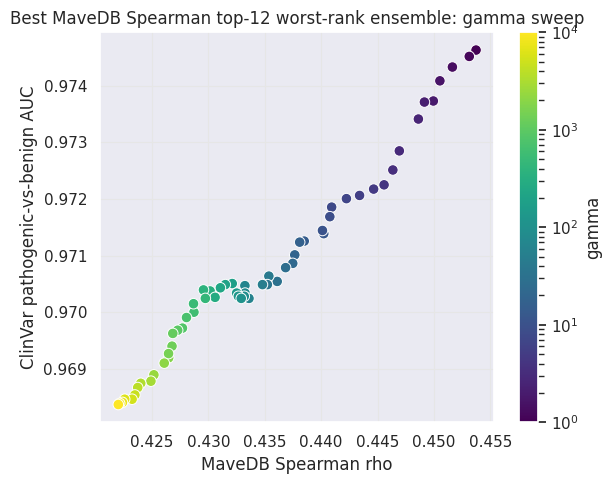

Gamma sweep summary table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_sweep_summary.csv
Gamma sweep scatter figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_spearman_auc.png
Component consistency by gamma: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/best_mavedb_spearman_top12_worst_rank_gamma_sweep/best_mavedb_spearman_top12_worst_rank_gamma_sweep_component_consistency.csv


In [12]:
if best_rank_gamma_metrics_path.is_file():
    best_rank_gamma_metrics_df = pd.read_csv(best_rank_gamma_metrics_path)
    best_rank_gamma_metrics_df["mavedb_spearman_rank"] = pd.to_numeric(best_rank_gamma_metrics_df["spearman_rho"], errors="coerce").rank(ascending=False, method="min")
    best_rank_gamma_metrics_df["auc_rank"] = pd.to_numeric(best_rank_gamma_metrics_df["auc"], errors="coerce").rank(ascending=False, method="min")
    best_rank_gamma_metrics_df["spearman_auc_rank_score"] = best_rank_gamma_metrics_df[["mavedb_spearman_rank", "auc_rank"]].mean(axis=1)
    best_rank_gamma_metrics_df = best_rank_gamma_metrics_df.sort_values(["spearman_auc_rank_score", "mavedb_spearman_rank", "auc_rank", "gamma"]).reset_index(drop=True)
    best_rank_gamma_summary_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_sweep_summary.csv"
    best_rank_gamma_metrics_df.to_csv(best_rank_gamma_summary_path, index=False)

    display_columns = [
        "gamma",
        "spearman_auc_rank_score",
        "mavedb_spearman_rank",
        "auc_rank",
        "spearman_rho",
        "auc",
        "mean_component_rep_consistency",
        "n_variants",
        "n_score_sequences",
    ]
    display(
        best_rank_gamma_metrics_df[[col for col in display_columns if col in best_rank_gamma_metrics_df.columns]].head(15).assign(
            gamma=lambda df: pd.to_numeric(df["gamma"], errors="coerce").map(lambda x: f"{x:.4g}"),
            spearman_auc_rank_score=lambda df: pd.to_numeric(df["spearman_auc_rank_score"], errors="coerce").round(2),
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
            mean_component_rep_consistency=lambda df: pd.to_numeric(df["mean_component_rep_consistency"], errors="coerce").round(3),
        )
    )

    gamma_scatter_fig = h.plot_gamma_spearman_auc_scatter(
        best_rank_gamma_metrics_df,
        best_rank_gamma_figure_path,
        "Best MaveDB Spearman top-12 worst-rank ensemble: gamma sweep",
        figure_dpi=FIGURE_DPI,
    )
    if gamma_scatter_fig is not None:
        plt.show()
    print(f"Gamma sweep summary table: {best_rank_gamma_summary_path}")
    print(f"Gamma sweep scatter figure: {best_rank_gamma_figure_path}")
    print(f"Component consistency by gamma: {best_rank_gamma_component_consistency_path}")
else:
    best_rank_gamma_metrics_df = pd.DataFrame()
    print("No gamma sweep metrics found yet.")
    print(f"Run: sbatch {best_rank_gamma_script_path}")
    print(f"Expected metrics: {best_rank_gamma_metrics_path}")

## PCA Variance Breakdown For The Best MaveDB-Spearman Top-12 PCA Concat Model

This summarizes the selected PCA components per SAE layer and the variance explained by those selected components. If both gamma-objective runs exist, the MaveDB-gamma component table is preferred; the PCA component choices are independent of gamma selection.

,model_short,model,layer,model_label,selected_pcs,selected_explained_variance_ratio,mean_selected_explained_variance_ratio,max_selected_explained_variance_ratio,first_selected_concat_component,last_selected_concat_component,available_pcs_in_component_table,available_explained_variance_ratio,selected_fraction_of_table_variance
0,ESMC-300M,biohub/ESMC-300M,29,ESMC-300M Layer_29 DeltaEmbSAE_max_pool_batcht...,64,0.2655,0.0041,0.0317,17,747,64,0.2655,1.0
1,ESMC-300M,biohub/ESMC-300M,30,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,64,0.3792,0.0059,0.0293,21,456,64,0.3792,1.0
2,ESMC-600M,biohub/ESMC-600M,13,ESMC-600M Layer_13 DeltaEmbSAE_max_pool_batcht...,64,0.3537,0.0055,0.0783,1,767,64,0.3537,1.0
3,ESMC-600M,biohub/ESMC-600M,17,ESMC-600M Layer_17 DeltaEmbSAE_max_pool_batcht...,64,0.6296,0.0098,0.1135,0,658,64,0.6296,1.0
4,ESMC-600M,biohub/ESMC-600M,29,ESMC-600M Layer_29 DeltaEmbSAE_max_pool_batcht...,64,0.4121,0.0064,0.0583,3,692,64,0.4121,1.0
5,ESMC-600M,biohub/ESMC-600M,30,ESMC-600M Layer_30 DeltaEmbSAE_max_pool_batcht...,64,0.3990,0.0062,0.0471,9,727,64,0.3990,1.0
6,ESMC-600M,biohub/ESMC-600M,31,ESMC-600M Layer_31 DeltaEmbSAE_max_pool_batcht...,64,0.3652,0.0057,0.0330,15,711,64,0.3652,1.0
7,ESMC-600M,biohub/ESMC-600M,32,ESMC-600M Layer_32 DeltaEmbSAE_max_pool_batcht...,64,0.3989,0.0062,0.0445,10,734,64,0.3989,1.0
8,ESMC-600M,biohub/ESMC-600M,33,ESMC-600M Layer_33 DeltaEmbSAE_max_pool_batcht...,64,0.3185,0.0050,0.0325,16,686,64,0.3185,1.0
9,ESMC-600M,biohub/ESMC-600M,34,ESMC-600M Layer_34 DeltaEmbSAE_max_pool_batcht...,64,0.3480,0.0054,0.0540,5,740,64,0.3480,1.0


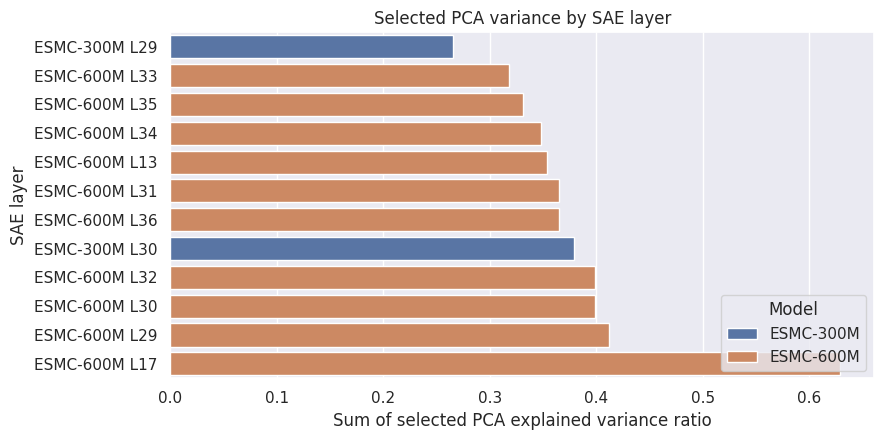

PCA component table used: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/mavedb_spearman/pca_concat__best_mavedb_spearman_top12__mavedb_spearman/pca_concat__best_mavedb_spearman_top12__mavedb_spearman_pca_components.csv
Gamma objective for selected component table: mavedb_spearman
PCA variance summary table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.csv
Selected PCA components table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_components.csv
PCA variance figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.png


In [13]:
PCA_VARIANCE_MODEL_FILTER = f"best_mavedb_spearman_top{COLLECTION_TOP_N}"
PCA_VARIANCE_OBJECTIVE_PRIORITY = {"mavedb_spearman": 0, "cross_replicate_consistency": 1}

pca_variance_component_path = None
pca_variance_objective = None

if not esmc_ensemble_metrics_df.empty and "component_table_path" in esmc_ensemble_metrics_df.columns:
    pca_variance_candidates = esmc_ensemble_metrics_df[
        esmc_ensemble_metrics_df["aggregation"].eq("pca_concat")
        & esmc_ensemble_metrics_df["model_filter"].eq(PCA_VARIANCE_MODEL_FILTER)
        & esmc_ensemble_metrics_df["component_table_path"].notna()
    ].copy()
    if not pca_variance_candidates.empty:
        if "gamma_selection_objective" not in pca_variance_candidates.columns:
            pca_variance_candidates["gamma_selection_objective"] = "cross_replicate_consistency"
        pca_variance_candidates["_objective_priority"] = pca_variance_candidates["gamma_selection_objective"].map(PCA_VARIANCE_OBJECTIVE_PRIORITY).fillna(99)
        pca_variance_candidates = pca_variance_candidates.sort_values(["_objective_priority", "gamma_selection_objective"])
        for _, candidate_row in pca_variance_candidates.iterrows():
            candidate_path = Path(candidate_row["component_table_path"])
            if candidate_path.is_file():
                pca_variance_component_path = candidate_path
                pca_variance_objective = candidate_row.get("gamma_selection_objective", "")
                break

if pca_variance_component_path is None:
    globbed_component_paths = sorted(
        (OUTPUT_ROOT / "pca_concat").glob(f"**/pca_concat__{PCA_VARIANCE_MODEL_FILTER}*_pca_components.csv"),
        key=lambda path: (0 if "__mavedb_spearman" in path.name else 1, str(path)),
    )
    for candidate_path in globbed_component_paths:
        if candidate_path.is_file():
            pca_variance_component_path = candidate_path
            pca_variance_objective = "mavedb_spearman" if "__mavedb_spearman" in candidate_path.name else "cross_replicate_consistency"
            break

if pca_variance_component_path is None:
    pca_variance_summary_df = pd.DataFrame()
    print(f"No PCA component table found for {PCA_VARIANCE_MODEL_FILTER}.")
else:
    pca_components_df = pd.read_csv(pca_variance_component_path)
    selected_flag = pca_components_df["selected"]
    if selected_flag.dtype == bool:
        selected_mask = selected_flag
    else:
        selected_mask = selected_flag.astype(str).str.lower().isin(["true", "1", "yes"])
    selected_pca_components_df = pca_components_df[selected_mask].copy()
    pca_components_df["layer"] = pd.to_numeric(pca_components_df["layer"], errors="coerce")
    selected_pca_components_df["layer"] = pd.to_numeric(selected_pca_components_df["layer"], errors="coerce")

    group_cols = ["model_short", "model", "layer", "model_label"]
    selected_summary = selected_pca_components_df.groupby(group_cols, dropna=False).agg(
        selected_pcs=("pc_idx", "count"),
        selected_explained_variance_ratio=("explained_variance_ratio", "sum"),
        mean_selected_explained_variance_ratio=("explained_variance_ratio", "mean"),
        max_selected_explained_variance_ratio=("explained_variance_ratio", "max"),
        first_selected_concat_component=("concat_component_idx", "min"),
        last_selected_concat_component=("concat_component_idx", "max"),
    ).reset_index()
    available_summary = pca_components_df.groupby(group_cols, dropna=False).agg(
        available_pcs_in_component_table=("pc_idx", "count"),
        available_explained_variance_ratio=("explained_variance_ratio", "sum"),
    ).reset_index()
    pca_variance_summary_df = selected_summary.merge(available_summary, on=group_cols, how="left")
    pca_variance_summary_df["selected_fraction_of_table_variance"] = (
        pca_variance_summary_df["selected_explained_variance_ratio"] / pca_variance_summary_df["available_explained_variance_ratio"]
    )
    pca_variance_summary_df = pca_variance_summary_df.sort_values(["model_short", "layer"]).reset_index(drop=True)

    pca_variance_summary_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.csv"
    pca_variance_selected_components_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_components.csv"
    pca_variance_figure_path = paths.figure_dir / "BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.png"
    pca_variance_summary_df.to_csv(pca_variance_summary_path, index=False)
    selected_pca_components_df.to_csv(pca_variance_selected_components_path, index=False)

    display(
        pca_variance_summary_df.assign(
            layer=lambda df: pd.to_numeric(df["layer"], errors="coerce").astype("Int64"),
            selected_explained_variance_ratio=lambda df: pd.to_numeric(df["selected_explained_variance_ratio"], errors="coerce").round(4),
            available_explained_variance_ratio=lambda df: pd.to_numeric(df["available_explained_variance_ratio"], errors="coerce").round(4),
            selected_fraction_of_table_variance=lambda df: pd.to_numeric(df["selected_fraction_of_table_variance"], errors="coerce").round(3),
            mean_selected_explained_variance_ratio=lambda df: pd.to_numeric(df["mean_selected_explained_variance_ratio"], errors="coerce").round(4),
            max_selected_explained_variance_ratio=lambda df: pd.to_numeric(df["max_selected_explained_variance_ratio"], errors="coerce").round(4),
        )
    )

    plot_df = pca_variance_summary_df.copy()
    plot_df["layer_label"] = plot_df["model_short"].astype(str) + " L" + pd.to_numeric(plot_df["layer"], errors="coerce").astype("Int64").astype(str)
    plot_df = plot_df.sort_values("selected_explained_variance_ratio", ascending=True)
    fig, ax = plt.subplots(figsize=(9.0, max(4.0, 0.38 * len(plot_df))))
    sns.barplot(
        data=plot_df,
        y="layer_label",
        x="selected_explained_variance_ratio",
        hue="model_short",
        dodge=False,
        ax=ax,
    )
    ax.set_xlabel("Sum of selected PCA explained variance ratio")
    ax.set_ylabel("SAE layer")
    ax.set_title("Selected PCA variance by SAE layer")
    ax.legend(title="Model", loc="lower right")
    fig.tight_layout()
    fig.savefig(pca_variance_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    print(f"PCA component table used: {pca_variance_component_path}")
    print(f"Gamma objective for selected component table: {pca_variance_objective}")
    print(f"PCA variance summary table: {pca_variance_summary_path}")
    print(f"Selected PCA components table: {pca_variance_selected_components_path}")
    print(f"PCA variance figure: {pca_variance_figure_path}")

## Plot Against Previous Layer-Level Results

This plot overlays the new ESM-C ensemble methods onto the existing layer-level Spearman/AUC results from `lower_context.ipynb`.

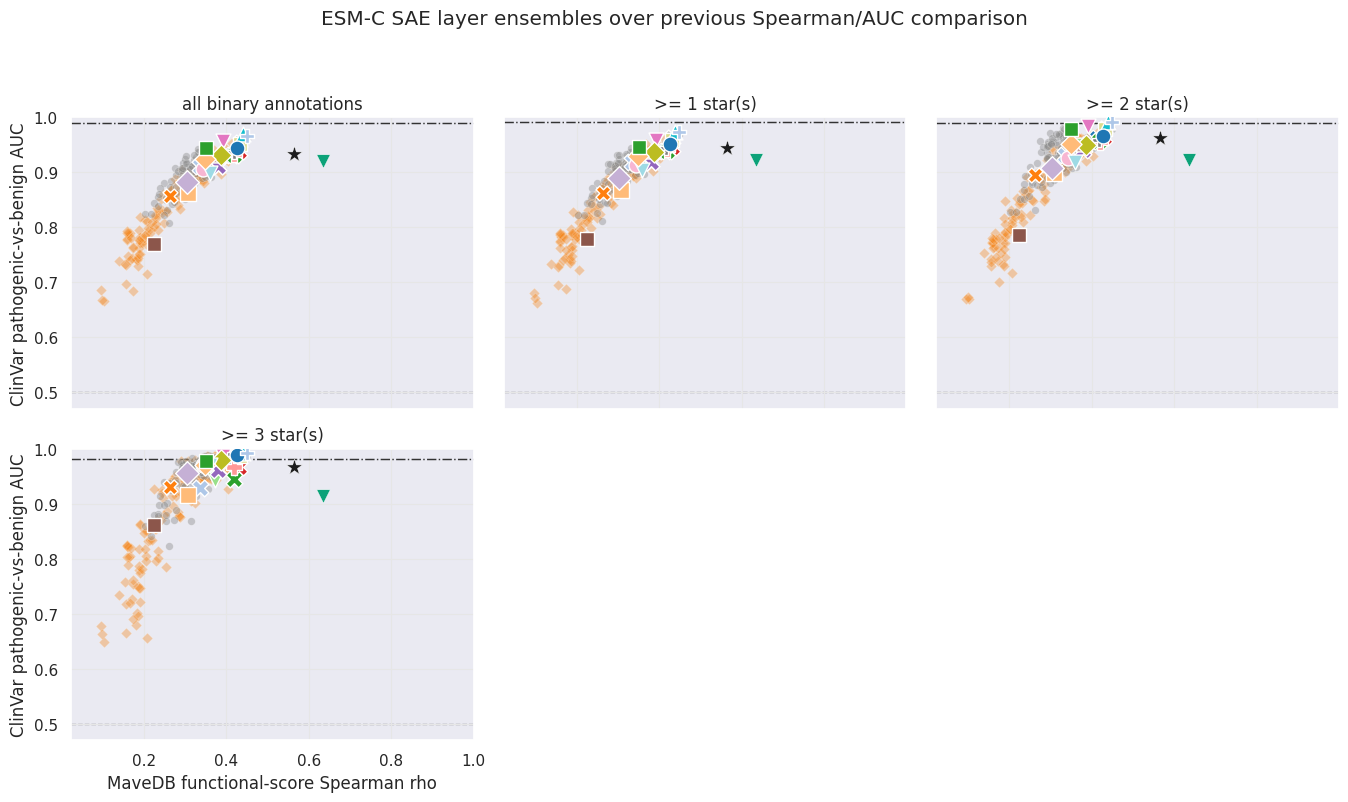

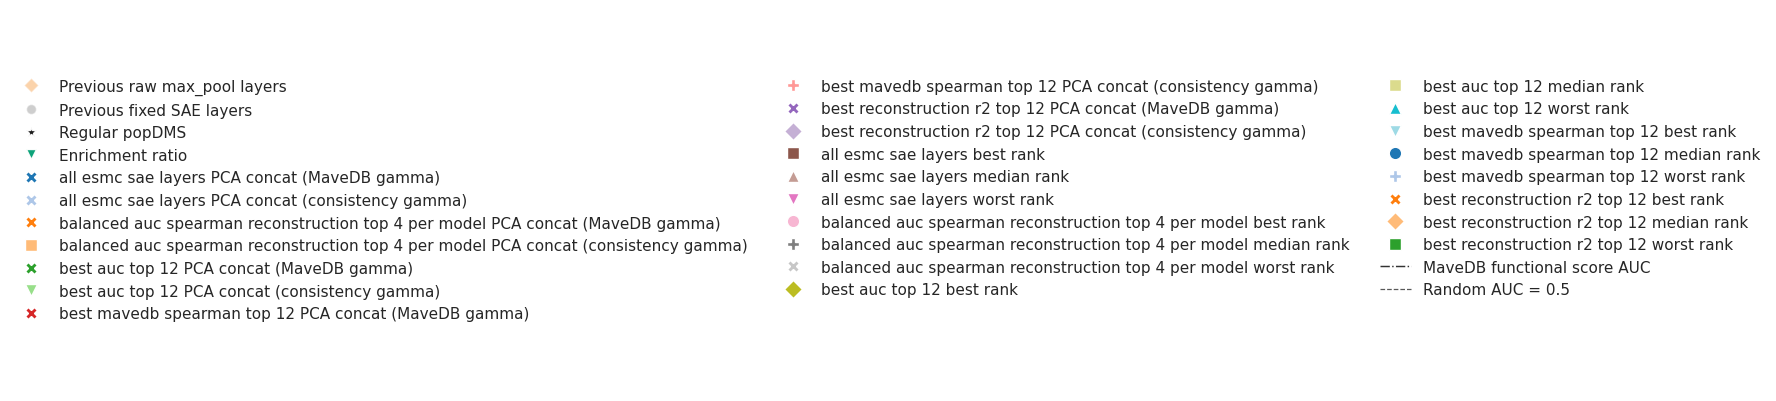

,review_filter,method_label,gamma_selection_objective,model_filter,spearman_rho,auc,n_variants
0,all binary annotations,all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.931,496
1,>= 1 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.939,491
2,>= 2 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.962,282
3,>= 3 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.978,132
4,>= 4 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,NaN,0
...,...,...,...,...,...,...,...
120,all binary annotations,best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.944,496
121,>= 1 star(s),best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.947,491
122,>= 2 star(s),best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.978,282
123,>= 3 star(s),best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.978,132


Combined figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_esmc_sae_layer_ensemble_with_previous_spearman_auc_by_review_stars.png
Separate legend figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_esmc_sae_layer_ensemble_spearman_auc_legend.png
Spearman/AUC plot rows table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_esmc_sae_layer_ensemble_spearman_auc_plot_rows.csv


In [14]:
if not esmc_ensemble_metrics_df.empty:
    previous_df = h.load_previous_metrics_for_combined_plot(
        all_binary_table_path=paths.spearman_auc_table_path,
        table_dir=paths.table_dir,
        star_combined_table_path=paths.spearman_auc_star_combined_table_path,
    )
    spearman_auc_plot_rows_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_spearman_auc_plot_rows.csv"
    esmc_ensemble_metrics_df.to_csv(spearman_auc_plot_rows_path, index=False)

    marker_cycle = ["P", "X", "D", "s", "^", "v", "o"]
    color_cycle = sns.color_palette("tab20", n_colors=max(20, esmc_ensemble_metrics_df["method_label"].nunique()))
    marker_specs = {}
    for idx, method_label in enumerate(esmc_ensemble_metrics_df["method_label"].drop_duplicates()):
        is_mavedb_gamma = "MaveDB gamma" in method_label
        marker_specs[method_label] = {
            "marker": "X" if is_mavedb_gamma else marker_cycle[idx % len(marker_cycle)],
            "size": 145 if "PCA" in method_label else 115,
            "color": color_cycle[idx % len(color_cycle)],
            "offset": (6, -9),
        }

    combined_figure_path = paths.figure_dir / "BRCA1_esmc_sae_layer_ensemble_with_previous_spearman_auc_by_review_stars.png"
    fig = h.plot_ensemble_with_previous(
        previous_df,
        esmc_ensemble_metrics_df,
        combined_figure_path,
        "ESM-C SAE layer ensembles over previous Spearman/AUC comparison",
        marker_specs,
        figure_dpi=FIGURE_DPI,
        review_star_thresholds=[1, 2, 3],
        annotate_points=False,
        include_legend=False,
    )
    plt.show()

    legend_figure_path = paths.figure_dir / "BRCA1_esmc_sae_layer_ensemble_spearman_auc_legend.png"
    legend_fig = h.plot_ensemble_comparison_legend(
        marker_specs,
        legend_figure_path,
        figure_dpi=FIGURE_DPI,
        ncol=3,
    )
    plt.show()

    display(
        esmc_ensemble_metrics_df[
            ["review_filter", "method_label", "gamma_selection_objective", "model_filter", "spearman_rho", "auc", "n_variants"]
        ].assign(
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        )
    )
    print(f"Combined figure: {combined_figure_path}")
    print(f"Separate legend figure: {legend_figure_path}")
    print(f"Spearman/AUC plot rows table: {spearman_auc_plot_rows_path}")
else:
    print("No ensemble metrics are available yet. Run or collect the ensemble task outputs first.")

## Gamma Consistency Plot Locations

Every PCA-concat task saves its cross-replicate consistency by gamma plot as `*_gamma_consistency.png`. The table below lists those exact paths.

In [15]:
if not esmc_ensemble_metrics_df.empty and "gamma_plot_path" in esmc_ensemble_metrics_df.columns:
    gamma_columns = ["method_label", "model_filter", "gamma_opt", "gamma_plot_path"]
    if "gamma_table_path" in esmc_ensemble_metrics_df.columns:
        gamma_columns.append("gamma_table_path")
    gamma_plot_df = (
        esmc_ensemble_metrics_df.dropna(subset=["gamma_plot_path"])
        .loc[lambda df: df["gamma_plot_path"].astype(str).ne("")]
        [gamma_columns]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    """display(gamma_plot_df)
    for _, row in gamma_plot_df.iterrows():
        plot_path = Path(row["gamma_plot_path"])
        display(Markdown(f"**{row['method_label']}**  \n`{plot_path}`"))
        if plot_path.is_file():
            display(Image(filename=str(plot_path), width=780))
        else:
            print(f"Missing gamma plot: {plot_path}")"""
print(f"PCA gamma consistency directory: {OUTPUT_ROOT / 'pca_concat'}")


PCA gamma consistency directory: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat


## Task Status Audit

In [16]:
status_files = sorted((OUTPUT_ROOT / "status").glob("*_status.json"))
status_rows = []
for status_path in status_files:
    with status_path.open() as handle:
        row = __import__("json").load(handle)
    row["status_path"] = str(status_path)
    status_rows.append(row)
status_df = pd.DataFrame(status_rows)
if not status_df.empty:
    display(status_df[[col for col in ["task_idx", "status", "task_type", "collection_name", "aggregation", "n_sources", "n_selected_components", "gamma_plot_path", "error", "status_path"] if col in status_df.columns]])
else:
    print(f"No status files found yet under {OUTPUT_ROOT / 'status'}")

,task_idx,status,task_type,collection_name,aggregation,n_sources,n_selected_components,gamma_plot_path,status_path
0,0,ok,pca_concat,all_esmc_sae_layers,NaN,66,1000.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,0,ok,rank_ensemble,all_esmc_sae_layers,rank_median,66,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,1,ok,pca_concat,best_auc_top12,NaN,12,768.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,1,ok,rank_ensemble,all_esmc_sae_layers,rank_worst,66,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,2,ok,pca_concat,best_mavedb_spearman_top12,NaN,12,768.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
5,2,ok,rank_ensemble,all_esmc_sae_layers,rank_best,66,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
6,3,ok,pca_concat,best_reconstruction_r2_top12,NaN,12,768.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
7,3,ok,rank_ensemble,best_auc_top12,rank_median,12,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
8,4,ok,pca_concat,balanced_auc_spearman_reconstruction_top4_per_...,NaN,8,512.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
9,4,ok,rank_ensemble,best_auc_top12,rank_worst,12,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Best Model Fitness Distribution By ClinVar Review Stars

Distribution of the top-ranked ensemble's fitness (rank) scores for ClinVar pathogenic vs. benign variants, paneled by review-star threshold. Pathogenic and benign histograms share bins and are drawn translucent so their overlap is visible, and each panel reports the corresponding AUC.

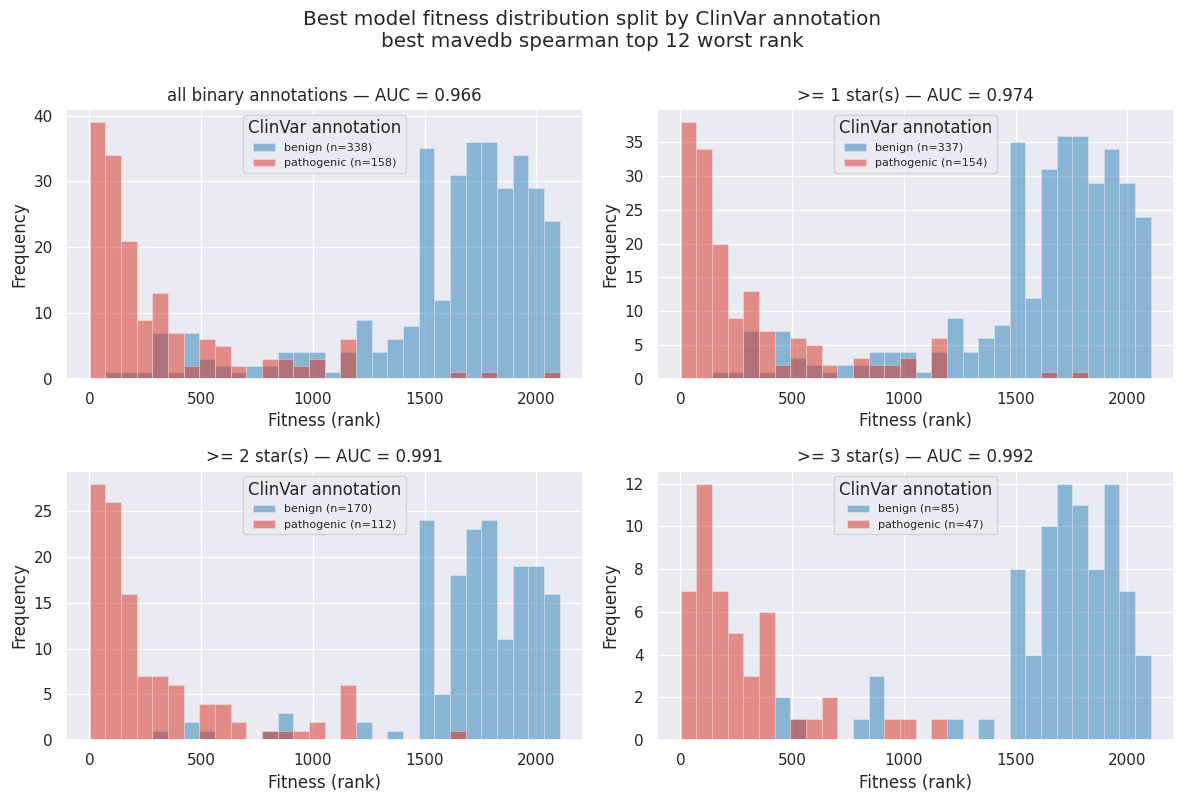

Best model (Spearman/AUC rank 1): best mavedb spearman top 12 worst rank
Best model fitness distribution figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_model_fitness_distribution_by_review_stars.png


In [17]:
# Best-model fitness-score distribution split by ClinVar pathogenic/benign across review-star thresholds.
if not performance_summary_df.empty:
    best_model_row = performance_summary_df.sort_values("spearman_auc_rank").iloc[0]
    best_model_label = best_model_row["method_label"]
    best_model_fitness_path = h.as_existing_path(best_model_row.get("fitness_path", ""))

    if best_model_fitness_path is None:
        print(f"No fitness table found for best model {best_model_label!r}; cannot plot score distributions.")
    else:
        best_fitness_df = pd.read_csv(best_model_fitness_path)[["SequenceIndex", "fitness"]].copy()
        best_fitness_df["SequenceIndex"] = best_fitness_df["SequenceIndex"].astype(str)
        best_fitness_df["fitness"] = pd.to_numeric(best_fitness_df["fitness"], errors="coerce")
        best_fitness_df = best_fitness_df.dropna(subset=["fitness"])

        pathogenicity_palette = {"benign": "#2c7fb8", "pathogenic": "#d7301f"}
        star_panels = []
        for min_review_stars, review_filter in h.review_star_specs():
            annotation_map = h.clinvar_binary_annotation_map(
                paths.clinvar_annotation_cache_path,
                primary_key="hgvs_nt",
                min_review_stars=min_review_stars,
            )
            panel_df = best_fitness_df.copy()
            panel_df["annotation"] = panel_df["SequenceIndex"].map(annotation_map)
            panel_df = panel_df[panel_df["annotation"].isin(["benign", "pathogenic"])].dropna(subset=["fitness"])
            if panel_df.empty:
                continue
            panel_auc = h.classification_metrics_for_fitness(panel_df)["auc"]
            star_panels.append((min_review_stars, review_filter, panel_df, panel_auc))

        if not star_panels:
            print("No pathogenic/benign annotated variants overlap the best-model fitness scores.")
        else:
            # Shared bins so the translucent pathogenic/benign overlap is comparable across panels.
            all_fitness = best_fitness_df["fitness"].to_numpy(dtype=float)
            bin_edges = np.linspace(np.nanmin(all_fitness), np.nanmax(all_fitness), 31)

            ncols = min(len(star_panels), 2)
            nrows = int(np.ceil(len(star_panels) / ncols))
            fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 4.0 * nrows), squeeze=False)
            axes_flat = axes.ravel()
            for ax, (min_review_stars, review_filter, panel_df, panel_auc) in zip(axes_flat, star_panels):
                for annotation in ["benign", "pathogenic"]:
                    values = panel_df.loc[panel_df["annotation"].eq(annotation), "fitness"].to_numpy(dtype=float)
                    ax.hist(
                        values,
                        bins=bin_edges,
                        color=pathogenicity_palette[annotation],
                        alpha=0.5,
                        label=f"{annotation} (n={len(values)})",
                        edgecolor="white",
                        linewidth=0.4,
                    )
                ax.set_title(f"{review_filter} \u2014 AUC = {panel_auc:.3f}")
                ax.set_xlabel("Fitness (rank)")
                ax.set_ylabel("Frequency")
                ax.legend(title="ClinVar annotation", fontsize=8)
            for ax in axes_flat[len(star_panels):]:
                ax.axis("off")
            fig.suptitle(
                f"Best model fitness distribution split by ClinVar annotation\n{best_model_label}",
                y=1.0,
            )
            fig.tight_layout()
            best_model_distribution_figure_path = paths.figure_dir / "BRCA1_best_model_fitness_distribution_by_review_stars.png"
            fig.savefig(best_model_distribution_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
            plt.show()
            print(f"Best model (Spearman/AUC rank 1): {best_model_label}")
            print(f"Best model fitness distribution figure: {best_model_distribution_figure_path}")
else:
    print("No performance summary is available yet. Run or collect the ensemble task outputs first.")


## Best Model Per-Component Contribution (Worst-Rank Source)

The best ensemble aggregates the 12 chosen SAE model/layers by taking the worst (minimum) per-variant rank across components. For each variant the worst rank is supplied by exactly one component, so counting how often each component is that source shows how much each of the 12 chosen models drives the population's fitness scores.

In [ ]:
# How much each of the 12 chosen components drives the best ensemble: for each variant, count
# which component supplied the selected (worst) rank that the rank_worst aggregation keeps.
if not performance_summary_df.empty:
    best_model_row = performance_summary_df.sort_values("spearman_auc_rank").iloc[0]
    best_model_label = best_model_row["method_label"]
    best_model_aggregation = best_model_row["aggregation"]
    best_model_collection = best_model_row["model_filter"]

    if best_model_aggregation not in {"rank_worst", "rank_best"}:
        print(
            f"Best model {best_model_label!r} uses aggregation {best_model_aggregation!r}; "
            "per-component rank attribution only applies to rank_worst / rank_best ensembles."
        )
    elif best_model_collection not in collections:
        print(f"Collection {best_model_collection!r} for the best model is not in `collections`.")
    else:
        # Rebuild the component score matrix exactly as aggregate_fitness_rows does.
        component_rows = collections[best_model_collection]
        component_series = [h.load_ensemble_fitness_series(row) for _, row in component_rows.iterrows()]
        component_score_matrix = pd.concat(component_series, axis=1)
        component_rank_matrix = component_score_matrix.rank(method="average", ascending=True)

        # rank_worst keeps the minimum rank per variant; rank_best keeps the maximum.
        valid_variants = component_score_matrix.notna().sum(axis=1).gt(0)
        if best_model_aggregation == "rank_worst":
            selection_word = "worst"
            selected_component = component_rank_matrix[valid_variants].idxmin(axis=1)
        else:
            selection_word = "best"
            selected_component = component_rank_matrix[valid_variants].idxmax(axis=1)

        contribution_df = (
            selected_component.value_counts()
            .reindex(component_score_matrix.columns, fill_value=0)
            .sort_values(ascending=False)
            .rename_axis("component")
            .reset_index(name="n_variants_selected")
        )
        contribution_df["fraction"] = (
            contribution_df["n_variants_selected"] / contribution_df["n_variants_selected"].sum()
        )
        contribution_df["model_short"] = contribution_df["component"].str.split("_L").str[0]
        component_contribution_path = paths.table_dir / "BRCA1_best_model_worst_rank_component_contributions.csv"
        contribution_df.to_csv(component_contribution_path, index=False)
        display(contribution_df.assign(fraction=lambda d: d["fraction"].round(3)))

        family_palette = {
            short: color
            for short, color in zip(
                sorted(contribution_df["model_short"].unique()),
                sns.color_palette("Set2", n_colors=contribution_df["model_short"].nunique()),
            )
        }
        bar_colors = contribution_df["model_short"].map(family_palette)
        fig, ax = plt.subplots(figsize=(10.0, 5.0))
        bars = ax.bar(
            contribution_df["component"],
            contribution_df["n_variants_selected"],
            color=bar_colors,
            edgecolor="0.25",
            linewidth=0.6,
        )
        ax.bar_label(bars, padding=2, fontsize=8)
        ax.set_xlabel("Component SAE model / layer")
        ax.set_ylabel(f"# variants where this component supplied the {selection_word} rank")
        ax.set_title(f"Per-component contribution to the best ensemble ({selection_word}-rank)\n{best_model_label}")
        ax.tick_params(axis="x", rotation=45)
        for tick_label in ax.get_xticklabels():
            tick_label.set_ha("right")
        legend_handles = [plt.Rectangle((0, 0), 1, 1, color=family_palette[short]) for short in family_palette]
        ax.legend(legend_handles, list(family_palette), title="Model", loc="upper right")
        fig.tight_layout()
        component_contribution_figure_path = paths.figure_dir / "BRCA1_best_model_worst_rank_component_contributions.png"
        fig.savefig(component_contribution_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
        plt.show()
        print(f"Best model ({selection_word}-rank): {best_model_label}")
        print(f"Component contribution table: {component_contribution_path}")
        print(f"Component contribution figure: {component_contribution_figure_path}")
else:
    print("No performance summary is available yet. Run or collect the ensemble task outputs first.")
